#📌 Extração

In [ ]:
#Obtendo dados de APIs - pelo formato JSON
import pandas as pd
import requests
import json

dados = requests.get('https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json')
resultado = json.loads(dados.text)
df = pd.DataFrame(resultado)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


As informações retornadas pela API necessitam ser normalizadas

In [ ]:
#Normalizando os dados obtidos
import pandas as pd
df = pd.json_normalize(resultado)

# Ajustando nome das colunas
df.columns = [c.split('.')[-1] for c in df.columns]
df = df.rename(columns={
    "Monthly": "Charges.Monthly",
    "Total": "Charges.Total"
})

df




,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformação

[Link para o dicionário de dados](https://github.com/alura-cursos/challenge2-data-science/blob/main/TelecomX_dicionario.md)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


### Avaliando possíveis inconsistências

In [ ]:
# Define função para Analise do DataFrame
def Analisa_Base(DadosTemp):
  # Criando um DataFrame para armazenar as propriedades de cada campo da base de dados
  DadosRetorno = pd.DataFrame(columns=['Campo', 'Tipo', 'Categorico', 'Não Nulos','Nulos'])
  # Armazena o nome das colunas
  Colunas = DadosTemp.columns
  # Cria uma columa de controle temporária
  DadosTemp['CampoTemp'] = 1

  for i in Colunas:
      x = DadosTemp.groupby(i)['CampoTemp'].count().reset_index().rename(columns={str(i):'Conteudo','CampoTemp':'Qtde'})
      x['Campo'] = i
      x['Não Nulos'] = DadosTemp[i].count()
      x['Nulos'] = DadosTemp[i].isna().sum()
      x['Tipo'] = DadosTemp[i].dtype


      AgrupaConteudo = ""
      x = x.sort_values(by='Qtde', ascending=False)

      if DadosTemp[i].dtype != "float64":

        if len(x) > 30:
          if "id" in i.lower():
            AgrupaConteudo = "Provável campo ID "
          else:
            AgrupaConteudo = "Quantidade de Categóricos Excedida "
        else:

          for j in range(len(x)):
            AgrupaConteudo = AgrupaConteudo + str(x.iloc[j,x.columns.get_loc('Conteudo')]) + " : " + str(int(x.iloc[j,x.columns.get_loc('Qtde')])) + "\n"

        x['Categorico'] = AgrupaConteudo[:-1]

      else:
        x['Categorico'] = \
        f'Média : {DadosTemp[i].mean():.2f}' \
        + f'\nMediana : {DadosTemp[i].median():.2f}' \
        + f'\nDesvio Padrão : {DadosTemp[i].std():.2f}' \
        + f'\nMinimo : {DadosTemp[i].min():.2f}' \
        + f'\nMáximo : {DadosTemp[i].max():.2f}' \
        + f'\nSoma : {DadosTemp[i].sum():.2f}' \
        + f'\nQ1 : {DadosTemp[i].quantile(0.25):.2f}' \
        + f'\nQ2 : {DadosTemp[i].quantile(0.50):.2f}' \
        + f'\nQ3 : {DadosTemp[i].quantile(0.75):.2f}'


      DadosRetorno = pd.concat([DadosRetorno,x], ignore_index=True)


  DadosTemp.drop(columns=['CampoTemp'], inplace=True)
  DadosRetorno = DadosRetorno[['Campo', 'Tipo', 'Categorico', 'Não Nulos','Nulos']].drop_duplicates().reset_index(drop=True)
  return DadosRetorno

In [ ]:
# Resultado preliminar da análise dos dados
Analise = Analisa_Base(df).style
Analise

,Campo,Tipo,Categorico,Não Nulos,Nulos
0,customerID,object,Provável campo ID,7267,0
1,Churn,object,No : 5174 Yes : 1869 : 224,7267,0
2,gender,object,Male : 3675 Female : 3592,7267,0
3,SeniorCitizen,int64,0 : 6085 1 : 1182,7267,0
4,Partner,object,No : 3749 Yes : 3518,7267,0
5,Dependents,object,No : 5086 Yes : 2181,7267,0
6,tenure,int64,Quantidade de Categóricos Excedida,7267,0
7,PhoneService,object,Yes : 6560 No : 707,7267,0
8,MultipleLines,object,No : 3495 Yes : 3065 No phone service : 707,7267,0
9,InternetService,object,Fiber optic : 3198 DSL : 2488 No : 1581,7267,0


**Análise inicial:**
Campo Churn contém 224 casos não nulos, porém sem categoria definida
Campo Charges.Total deveria ser numérico (deve haver "sujeira").
Campo MultipleLines: a quantidade na categoria "No phone service" é compatível com PhoneService = No.
Campos referentes a serviços de internet: Quantidade na categoria "No Internet Service" compatível com InternetService = No

In [ ]:
# Verificando duplicidades de ID
print(f'QUantidade total de registros: {df['customerID'].count()}')
print(f'Quantidade de registros únicos: {df['customerID'].nunique()}')


QUantidade total de registros: 7267
Quantidade de registros únicos: 7267


In [ ]:
# Verificando a consistência das informações entre os campos
Inconsistencias = []
Inconsistencias.append(df[(df['PhoneService'] == 'No') & (df['MultipleLines'] != 'No phone service')].index)
Inconsistencias.append(df[(df['InternetService'] == 'No') & (df['OnlineSecurity'] != 'No internet service')].index)
Inconsistencias.append(df[(df['InternetService'] == 'No') & (df['OnlineBackup'] != 'No internet service')].index)
Inconsistencias.append(df[(df['InternetService'] == 'No') & (df['DeviceProtection'] != 'No internet service')].index)
Inconsistencias.append(df[(df['InternetService'] == 'No') & (df['TechSupport'] != 'No internet service')].index)
Inconsistencias.append(df[(df['InternetService'] == 'No') & (df['StreamingTV'] != 'No internet service')].index)
Inconsistencias.append(df[(df['InternetService'] == 'No') & (df['StreamingMovies'] != 'No internet service')].index)
Inconsistencias

[Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64')]

Não foram identificadas inconsistências entre os conteúdos dos campos PhoneService e InternetService, comparados aos demais campos com categóricos que remetam a um desses dois campos. Aparentemente as informações estão coerentes.

In [ ]:
# Campo Charges.Total não foi carregado como float !

# Limpando espaços em branco em Charges.Total
df['Charges.Total'] = df['Charges.Total'].str.strip()
# Avaliando registros com Charges.Total em branco
df[df['Charges.Total']=='']


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


Há 11 registros contendo ´´ no campo 'Charges.Total' que impedem de transformar o campo em float.  
Analisando os 11 registros notei que todos possuem tenure = 0, o que me leva a crer que são novos clientes. Não há registros com tenure = 0 e valores no campo Charges.Total.
**Desta forma, estou assumindo que são novos clientes que ainda não efetuaram nenhum pagamento, deixarei o campo Charges.Total com valor = 0 para estes 11 casos.**


### Tratando inconsistências encontradas

In [ ]:
# Campo Charges.Total

# Trocando ´´ por 0, conforme explicação acima.
df.loc[df['Charges.Total'] == '', 'Charges.Total'] = 0

# Convertendo o campo para float
df['Charges.Total']=df['Charges.Total'].astype(float)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
# Campo Churn com valores ''
df[df['Churn']=='']

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.30
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.10
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.20
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.20
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.90


Não foi possível determinar o valor correto do campo Churn para os registros sem categórico correto. Como são apenas 224 registros, que **representam 3,08%** da base de dados, **eliminarei estes registros da análise.**

In [ ]:
# Removendo os registros com Churn = ''
df_tratado = df[df['Churn'] != ''].copy()

In [ ]:
# Criando a coluna Contas_Diarias
df_tratado['Contas_Diarias'] = round(df_tratado['Charges.Monthly'] / 30,2)

In [ ]:
df_tratado.head(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


### Padronização e transformação de Campos

In [ ]:
# Transformando campos com conteúdo "Yes/No" ou "1/0" em campos booleanos
# Transforma conteúdos 'No phone service' e 'No internet service' em False para simplificar as análises
df_tratado['SeniorCitizen'] = df_tratado['SeniorCitizen'].astype(bool)

campos_booleanos = ['Churn','Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity'\
                    ,'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']
for i in campos_booleanos:
  df_tratado[i] = df_tratado[i].map({'Yes': True, 'No': False, 'No phone service': False,'No internet service': False})


In [ ]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   bool   
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   bool   
 4   Partner           7043 non-null   bool   
 5   Dependents        7043 non-null   bool   
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   bool   
 8   MultipleLines     7043 non-null   bool   
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   bool   
 11  OnlineBackup      7043 non-null   bool   
 12  DeviceProtection  7043 non-null   bool   
 13  TechSupport       7043 non-null   bool   
 14  StreamingTV       7043 non-null   bool   
 15  StreamingMovies   7043 non-null   bool   
 16  Contract          7043 non-null   object 
 17  

In [ ]:
# Renomeando as colunas para facilitar o entendimento
df_tratado.columns = ['customerID', 'Churn', 'Gênero', 'Cliente Senior', 'Possui parceiro(a)',
       'Possui Dependentes', 'Meses de Contrato', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Tipo de Contrato',
       'Conta Digital', 'Método de Pagamento', 'Gasto Mensal', 'Gasto Total',
       'Gasto Diário']


#📊 Carga e análise

### Análise descritiva

In [ ]:
# Resultado após tratamento dos dados
Analise = Analisa_Base(df_tratado).style
Analise

,Campo,Tipo,Categorico,Não Nulos,Nulos
0,customerID,object,Provável campo ID,7043,0
1,Churn,bool,False : 5174 True : 1869,7043,0
2,Gênero,object,Male : 3555 Female : 3488,7043,0
3,Cliente Senior,bool,False : 5901 True : 1142,7043,0
4,Possui parceiro(a),bool,False : 3641 True : 3402,7043,0
5,Possui Dependentes,bool,False : 4933 True : 2110,7043,0
6,Meses de Contrato,int64,Quantidade de Categóricos Excedida,7043,0
7,PhoneService,bool,True : 6361 False : 682,7043,0
8,MultipleLines,bool,False : 4072 True : 2971,7043,0
9,InternetService,object,Fiber optic : 3096 DSL : 2421 No : 1526,7043,0


In [ ]:
df_tratado.describe()

,Meses de Contrato,Gasto Mensal,Gasto Total,Gasto Diário
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158675
std,24.559481,30.090047,2266.794470,1.003088
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


### Distribuição da Evasão

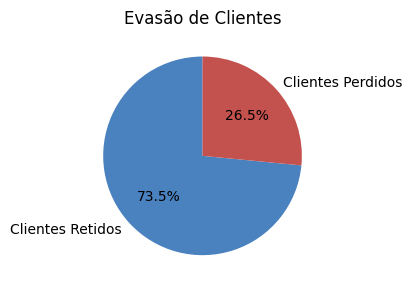

In [ ]:
# Demonstrar graficamente a distribuição da evasão - campo Churn
import seaborn as sns
import matplotlib.pyplot as plt

Evasao = df_tratado['Churn'].value_counts()

# Criar figura e eixo com tamanho definido
fig, ax = plt.subplots(figsize=(4, 4))

# Gráfico de Pizza
ax.pie(
    Evasao,
    labels=['Clientes Retidos', 'Clientes Perdidos'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4A81BF', '#C3514E']
)

ax.set_title('Evasão de Clientes', fontsize=12)

# Ajusta layout
fig.tight_layout()

# Salvar em PNG
fig.savefig('evasao_clientes.png',dpi=300,bbox_inches='tight')

plt.show()


###Contagem de Evasão por Variáveis Categóricas

In [ ]:
# Identificando as colunas categóricas
Colunas_Categoricas = list(df_tratado.select_dtypes(include=['object']).columns)
Colunas_Categoricas.pop(0)  # Apagar a coluna "customerID"
Colunas_Categoricas

['Gênero', 'InternetService', 'Tipo de Contrato', 'Método de Pagamento']

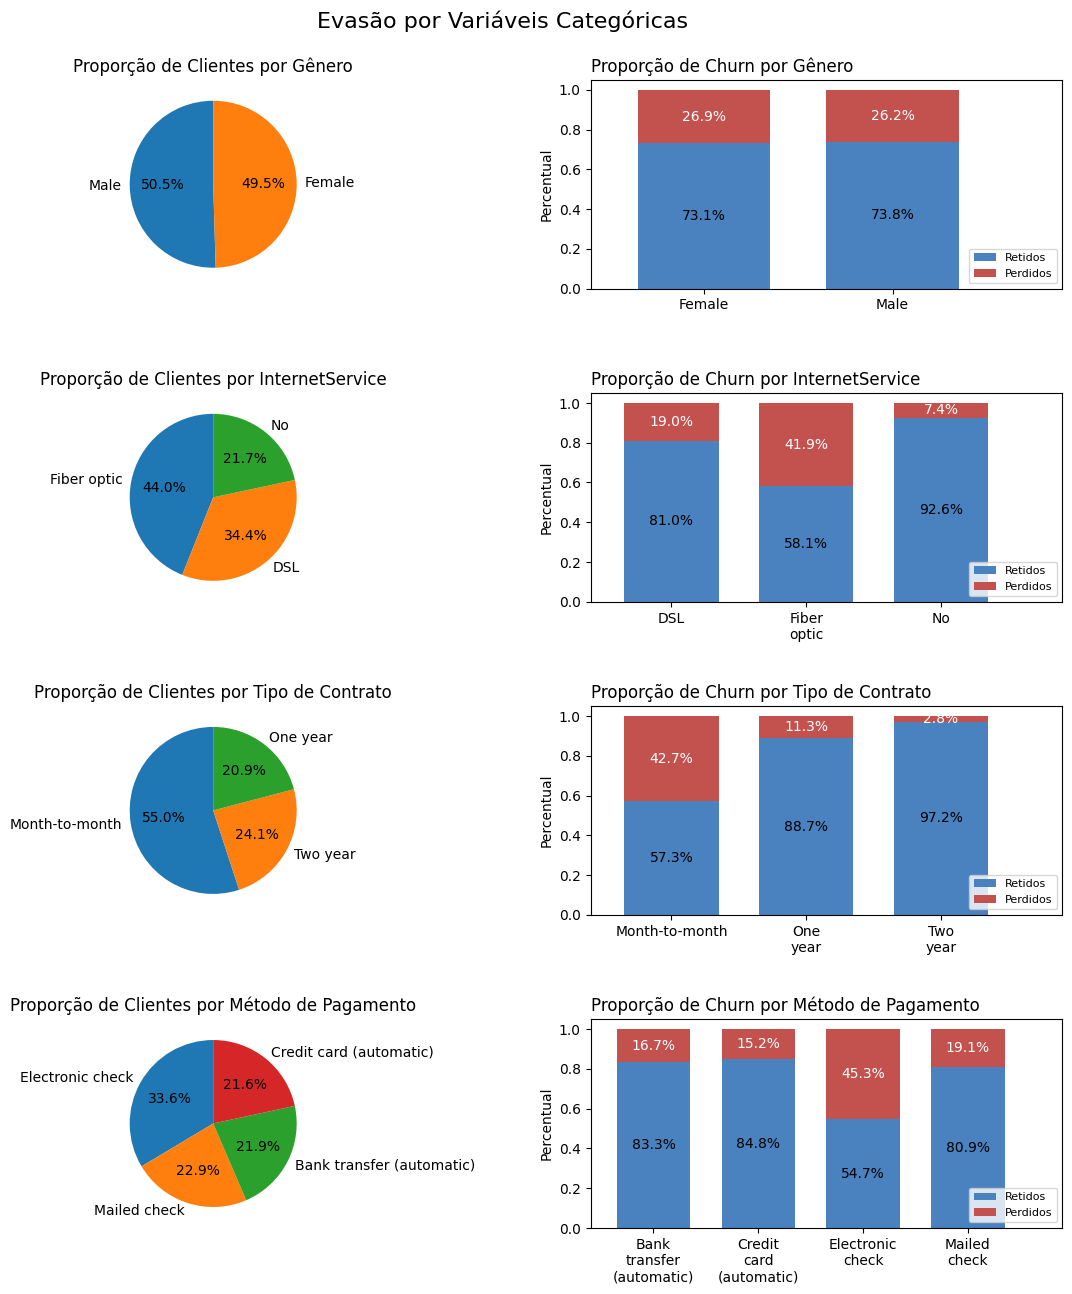

In [ ]:
# Criar gráficos para análise

Qtde_Linhas = len(Colunas_Categoricas)
Altura = Qtde_Linhas * 3.5

fig, axs = plt.subplots(Qtde_Linhas,2,figsize=(14,Altura))
fig.subplots_adjust(hspace=0.5, wspace=0.3, top=0.93)
fig.suptitle('Evasão por Variáveis Categóricas\n ', fontsize=16)

Linha = 0

for campo in Colunas_Categoricas:

  # Gráfico de Pizza
  campo_count = df_tratado[campo].value_counts()
  axs[Linha,0].pie(campo_count, labels=campo_count.index, autopct='%1.1f%%', startangle=90)
  axs[Linha,0].set_title('Proporção de Clientes por '+campo, fontsize=12) #, loc='left'

  # Gráfico de Barras
  campo_df = pd.DataFrame(df_tratado.groupby(campo)['Churn'].value_counts(normalize=True).unstack())
  campo_df.plot(kind='bar', stacked=True, ax=axs[Linha,1], width=0.7, \
                color=['#4A81BF', '#C3514E'],ylabel='Percentual',xlabel='') \
                #  Azul para False (não perdeu cliente) e Vermelho para True (perdeu cliente)

  axs[Linha,1].set_title('Proporção de Churn por '+campo, loc='left', fontsize=12)
  axs[Linha,1].legend(["Retidos", "Perdidos"],loc='lower right', fontsize=8)
  #axs[Linha,1].set_xticklabels(axs[Linha,1].get_xticklabels(), rotation=0)
  axs[Linha,1].set_xticklabels([label.replace(" ", "\n") for label in campo_df.index],rotation=0)
  min_x, max_x = axs[Linha,1].get_xlim()
  axs[Linha,1].set_xlim(min_x, max_x + 0.3)

  # Mostrar percentual dentro das barras
  for idx, (index, row) in enumerate(campo_df.iterrows()):
      bottom = 0
      for churn_val in [False, True]:
          value = row[churn_val]
          axs[Linha,1].text(
              idx,
              bottom + value/2,
              f"{value*100:.1f}%",
              ha='center',
              va='center',
              color="white" if churn_val else "black",
              fontsize=10
          )
          bottom += value

  Linha = Linha + 1

# Salvar em PNG

fig.savefig('evasao_categoricas.png',dpi=300,bbox_inches='tight')
plt.show()

Pelos gráficos acima, podemos observar as características de clientes mais propensos a cancelamento:


*   Clientes com serviço de internet por Fibra Óptica
*   Clientes com tipo de contrato mês-a-mês
*   Clientes que efetuam pagamento por Cheque eletrônico







###Contagem de Evasão por Variáveis Numéricas

In [ ]:
Colunas_numericas = df_tratado.select_dtypes(include=['number']).columns.tolist()
del Colunas_numericas[2:4]
Colunas_numericas

['Meses de Contrato', 'Gasto Mensal']

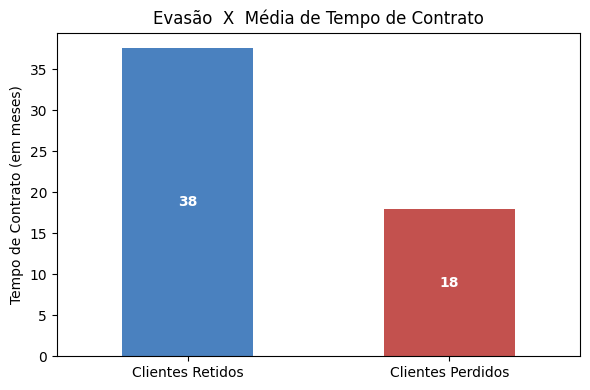

In [ ]:
# Gráfico Evasão x Tempo de contrato
ax = df_tratado.groupby('Churn')['Meses de Contrato'].mean().plot(
    kind='bar',
    color=['#4A81BF', '#C3514E'],
    figsize=(6,4)
)

ax.set_title('Evasão  X  Média de Tempo de Contrato')
ax.set_xticklabels(['Clientes Retidos', 'Clientes Perdidos'], rotation=0)
ax.set_xlabel('')
ax.set_ylabel('Tempo de Contrato (em meses)')

# Inserir a média no centro de cada barra
for bar in ax.patches:
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura / 2,                     # centro da barra
        f'{altura:.0f}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

plt.tight_layout()

# Salvar em PNG
#fig.savefig('evasao_TempoContrato.png',dpi=300,bbox_inches='tight')
plt.savefig('evasao_TempoContrato.png',dpi=300,bbox_inches='tight')

plt.show()


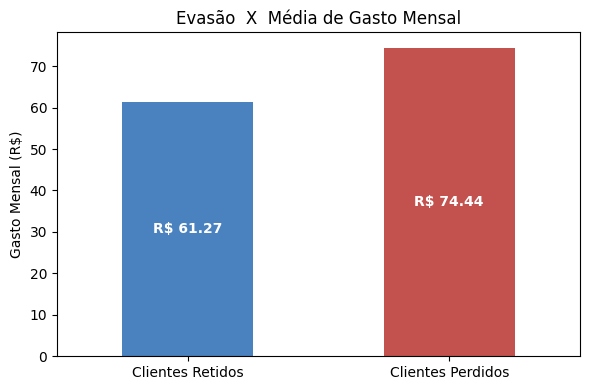

In [ ]:
# Gráfico Evasão x Média de gasto mensal
ax = df_tratado.groupby('Churn')['Gasto Mensal'].mean().plot(
    kind='bar',
    color=['#4A81BF', '#C3514E'],
    figsize=(6,4)
)

ax.set_title('Evasão  X  Média de Gasto Mensal')
ax.set_xticklabels(['Clientes Retidos', 'Clientes Perdidos'], rotation=0)
ax.set_xlabel('')
ax.set_ylabel('Gasto Mensal (R$)')

# Inserir a média no centro de cada barra
for bar in ax.patches:
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura / 2,                     # centro da barra
        f'R$ {altura:.2f}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

plt.tight_layout()

# Salvar em PNG
#fig.savefig('evasao_GastoMensal.png',dpi=300,bbox_inches='tight')
plt.savefig('evasao_GastoMensal.png',dpi=300,bbox_inches='tight')

plt.show()

In [ ]:
# Função para formatar as labels das Faixas de Valores
def format_faixa(interval):
    return f'{interval.left:,.0f} a {interval.right:,.0f}'.replace(',', '.')

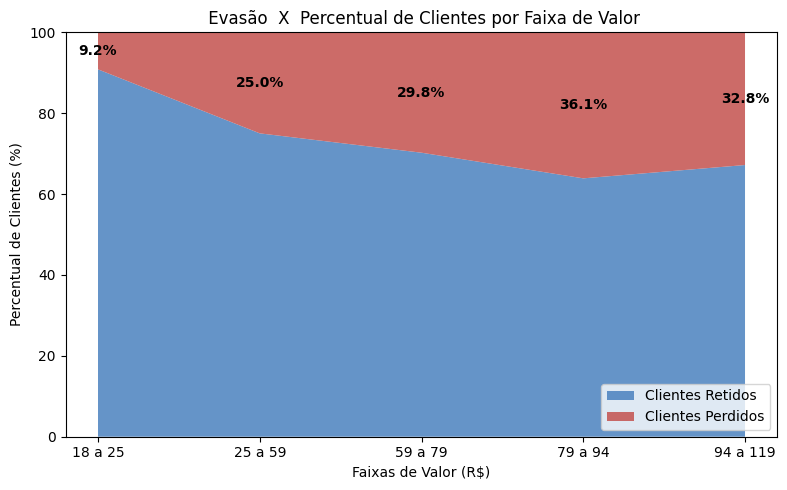

In [ ]:
# Gráfico de Área - Evasão x gastos mensais por faixa de valor
# Criar faixas de valores
df_tratado['Faixa_Valor'] = pd.qcut(
    df_tratado['Gasto Mensal'],
    q=5,
    duplicates='drop'
)
# Agrupar por faixas
area_df = (
    df_tratado
    .groupby(['Faixa_Valor', 'Churn'],observed=False)
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
area_pct = area_df.div(area_df.sum(axis=1), axis=0) * 100
color_map = {
    False: '#4A81BF',  # Retidos (azul)
    True:  '#C3514E'   # Perdidos
}

labels_faixa = [format_faixa(i) for i in area_pct.index]

plt.figure(figsize=(8,5))

plt.stackplot(
    labels_faixa,
    area_pct[False],
    area_pct[True],
    labels=['Clientes Retidos', 'Clientes Perdidos'],
    colors=[color_map[False], color_map[True]],
    alpha=0.85
)

# Inserir percentual de churn=True
for i, faixa in enumerate(area_pct.index):
    churn_pct = area_pct.loc[faixa, True]
    base = area_pct.loc[faixa, False]  # base da área empilhada

    plt.text(
        i,
        base + churn_pct / 2,
        f'{churn_pct:.1f}%',
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title(' Evasão  X  Percentual de Clientes por Faixa de Valor', fontsize=12)
plt.xlabel('Faixas de Valor (R$)')
plt.ylabel('Percentual de Clientes (%)')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.tight_layout()

# Salvar em PNG
#fig.savefig('evasao_clientes_porFaixaValor.png',dpi=300,bbox_inches='tight')
plt.savefig('evasao_clientes_porFaixaValor.png',dpi=300,bbox_inches='tight')

plt.show()




###Contagem de evasão por Variáveis Booleanas - Serviços oferecidos

In [ ]:
# Obtém as colunas que são variável booleanas
Colunas_Booleanas = df_tratado.select_dtypes(include=['bool']).columns.tolist()
# Apaga as colunas que não se referem a servicos oferecidos
del Colunas_Booleanas[0:4]
del Colunas_Booleanas[-1]
Colunas_Booleanas

['PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']

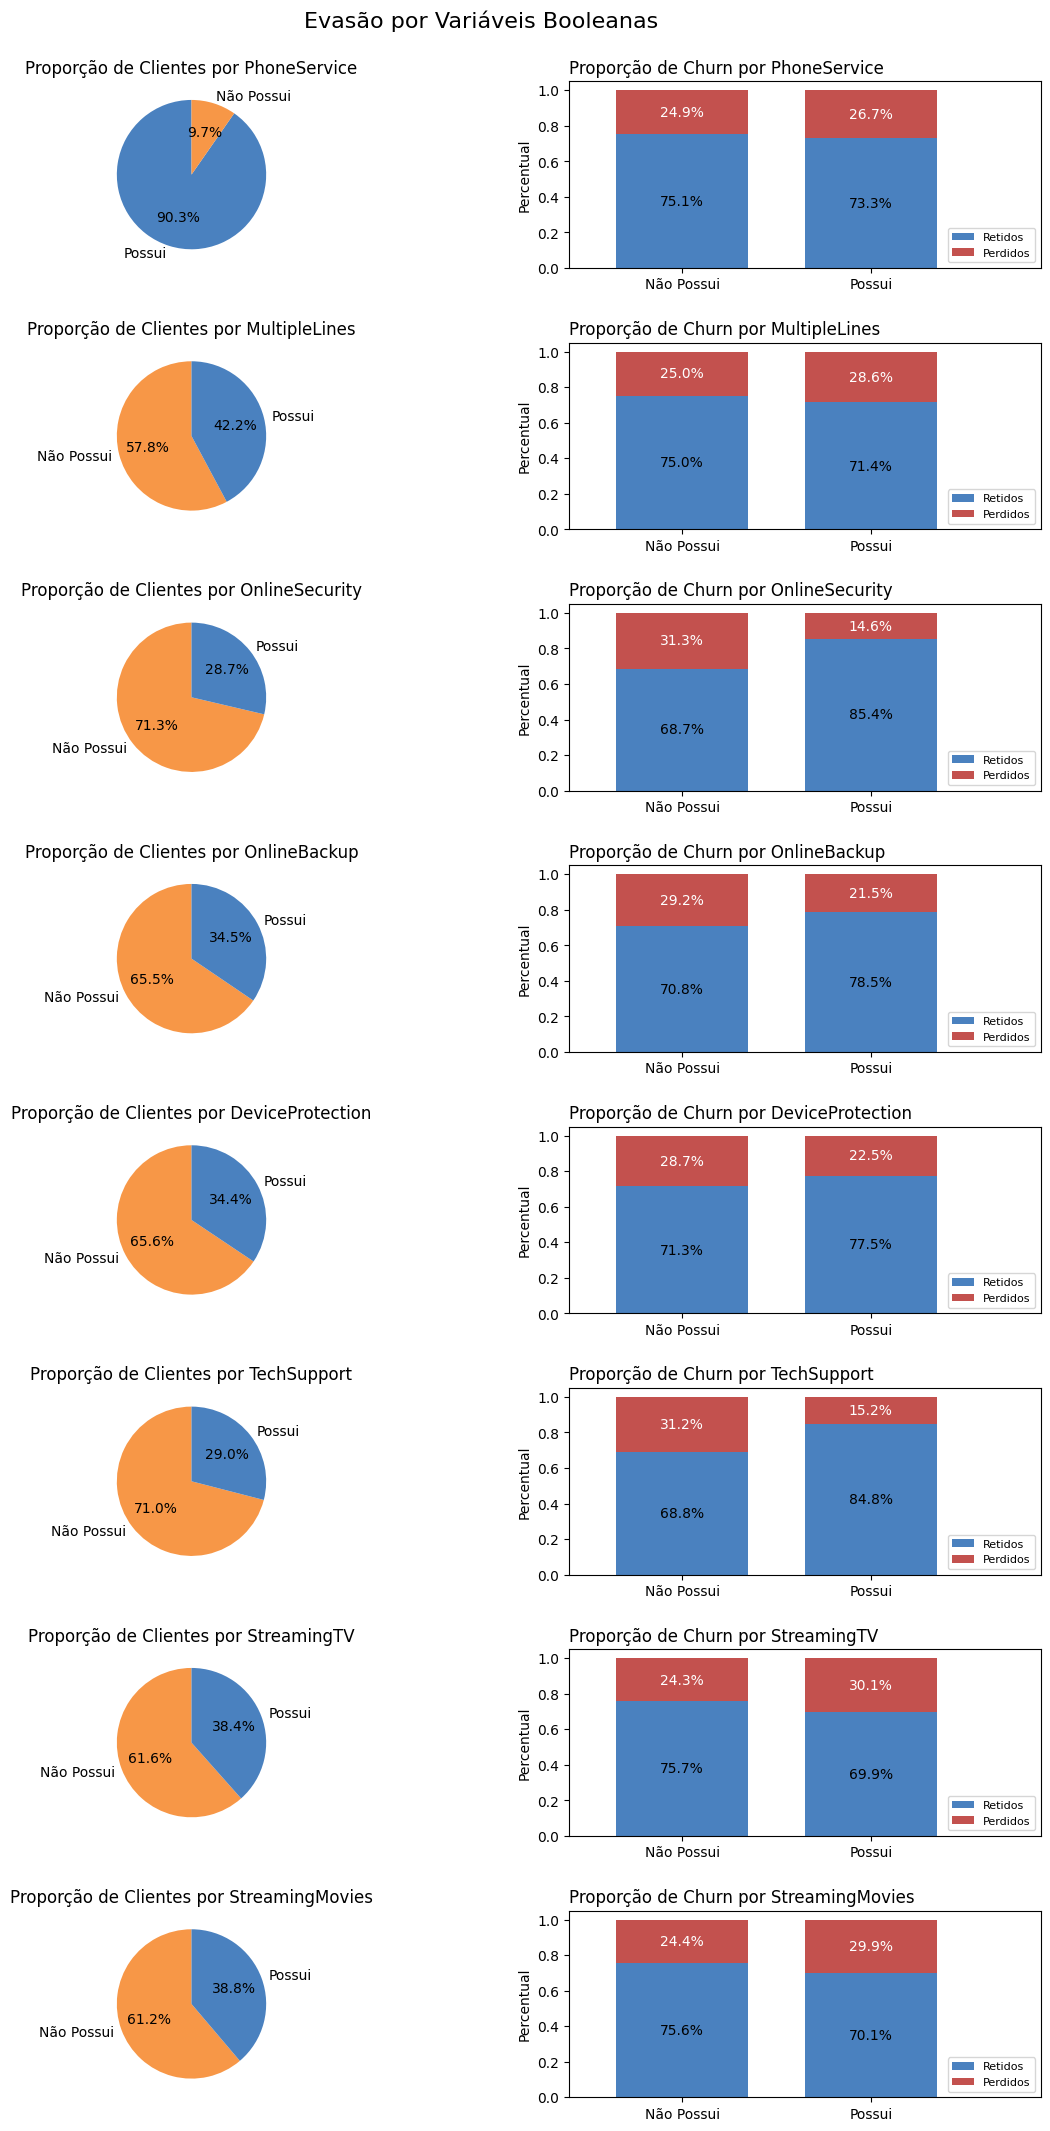

In [ ]:
from matplotlib import colors
Qtde_Linhas = len(Colunas_Booleanas)
Altura = Qtde_Linhas * 3

# Define as cores das fatias para True e False
color_map = {
    True:  '#4A81BF',   # laranja
    False: '#F79747'    # azul
}


fig, axs = plt.subplots(Qtde_Linhas,2,figsize=(14,Altura))
fig.subplots_adjust(hspace=0.4, wspace=0.3, top=0.95)
fig.suptitle('Evasão por Variáveis Booleanas', fontsize=16)

Linha = 0

for campo in Colunas_Booleanas:

  # Gráfico de Pizza
  campo_count = df_tratado[campo].value_counts()
  rotulos = campo_count.index.map({True: 'Possui', False: 'Não Possui'})
  # Fixa as cores das fatias
  indices = campo_count.index
  cores = [color_map[val] for val in indices]

  axs[Linha,0].pie(campo_count, labels=rotulos, autopct='%1.1f%%', startangle=90, colors=cores)
  axs[Linha,0].set_title('Proporção de Clientes por '+campo, fontsize=12) #, loc='left'

  # Gráfico de Barras
  campo_df = pd.DataFrame(df_tratado.groupby(campo)['Churn'].value_counts(normalize=True).unstack())
  rotulos = campo_df.index.map({True: 'Possui', False: 'Não Possui'})
  campo_df.plot(kind='bar', stacked=True, ax=axs[Linha,1], width=0.7, \
                color=['#4A81BF', '#C3514E'],ylabel='Percentual',xlabel='') \
                #  Azul para False (não perdeu cliente) e Vermelho para True (perdeu cliente)

  axs[Linha,1].set_title('Proporção de Churn por '+campo, loc='left', fontsize=12)
  axs[Linha,1].legend(["Retidos", "Perdidos"],loc='lower right', fontsize=8)
  axs[Linha,1].set_xticklabels(rotulos, rotation=0)
  #axs[Linha,1].set_xticklabels(axs[Linha,1].get_xticklabels(), rotation=0)
  #axs[Linha,1].set_xticklabels([label.replace(" ", "\n") for label in campo_df.index],rotation=0)
  min_x, max_x = axs[Linha,1].get_xlim()
  axs[Linha,1].set_xlim(min_x, max_x + 0.3)

  # Mostrar percentual dentro das barras
  for idx, (index, row) in enumerate(campo_df.iterrows()):
      bottom = 0
      for churn_val in [False, True]:
          value = row[churn_val]
          axs[Linha,1].text(
              idx,
              bottom + value/2,
              f"{value*100:.1f}%",
              ha='center',
              va='center',
              color="white" if churn_val else "black",
              fontsize=10
          )
          bottom += value

  Linha = Linha + 1

# Salvar em PNG
fig.savefig('evasao_booleanas.png',dpi=300,bbox_inches='tight')

plt.show()

#📄Relatorio Final

###Introdução


---


O objetivo deste estudo é analisar os motivos da Evasão de clientes (Churn) da Telecom X

###Limpeza e Tratamento de Dados


---


1.   Dados obtidos em formato JSON, diretamente da API indicada pelo cliente.
Efetuadas consistências da integridade dos dados, duplicidades, campos nulos, etc.
2.   Tratados 11 registros com caracteres não numéricos no campo Charges.Total. Modificados para 0 (zero) devido ao campo tenure (meses de contrato) estar igual a o (provavelmente novos clientes).
3.   Desprezados 224 registros (3,08% da base de dados) devido ao campo Churn apresentar informações inconclusivas (conteúdo = '')
4.   Renomeadas algumas colunas para facilitar o entendimento quanto ao seu conteúdo.



###Análise Exploratória de Dados


---


Foram analisados os campos categóricos, numéricos e booleanos relacionados aos serviços adicionais de internet.
Identificou-se uma taxa atual de evasão de 26,5%, indicando que mais de um quarto da base de clientes foi perdida.


### Evasão de Clientes
<img width='400px' src='https://drive.google.com/uc?id=1jhLpCVVIIr6bs6FjnybxxHAPv78LtHgV'>


### Gastos Mensais

Observa-se que a média de gastos mensais é mais elevada entre os clientes que evadiram, o que sugere que o custo dos serviços pode ser um dos principais fatores associados à evasão. Essa evidência é corroborada pelo gráfico Evasão x Faixas de Gastos Mensais, no qual se verifica um aumento expressivo da taxa de evasão a partir de gastos mensais superiores a R$ 59,00.

<img width='470px' src='https://drive.google.com/uc?id=1VkIf3PwqcZ3QD5mVfYiMHdMJoNIzTA6z'>    <img width='500px' src='https://drive.google.com/uc?id=1uV0qB6UZ7thq01rXDLUL2YXvdyiSPnbV'>


## Tempo Contrato
Observa-se também que a evasão é mais acentuada entre os clientes com menor tempo de contrato, indicando maior vulnerabilidade à perda nos estágios iniciais do relacionamento.

<img width='400px' src='https://drive.google.com/uc?id=1qbqgLKVWAqJL_smXtcJCTJ4CW9j0-fAW'>

## Categóricas
A análise das variáveis categóricas indica que a evasão é mais elevada, de forma independente, entre os clientes que utilizam a tecnologia de fibra óptica, entre aqueles que optaram por contratos do tipo mês a mês e entre os que escolheram o cheque eletrônico como meio de pagamento, não sendo necessariamente a combinação simultânea desses fatores.

<img width='800px' src='https://drive.google.com/uc?id=1pgIgLrZTGYupgMZI1BwVkwtwlnJBB_Vr'>


## Serviços disponíveis
Observa-se uma menor taxa de evasão entre os clientes que contrataram serviços adicionais ao serviço de internet, como backup, segurança online e suporte técnico, entre outros, o que sugere uma maior percepção de valor em relação aos valores pagos.

<img width='800px' src='https://drive.google.com/uc?id=1R4_TRmzfD11B1MGdkBX1BZWPBm1N5H8s'>


###Conclusões e Insights


---


A análise dos dados revelou uma taxa de evasão de 26,5%, indicando a perda de mais de um quarto da base de clientes. Observa-se que a evasão é mais pronunciada entre clientes com menor tempo de contrato, evidenciando maior vulnerabilidade nos estágios iniciais do relacionamento.

Do ponto de vista financeiro, os clientes que evadiram apresentam gastos mensais médios mais elevados, com um aumento expressivo da evasão a partir de valores superiores a R$ 59,00, sugerindo sensibilidade ao preço e à percepção de custo-benefício.

A avaliação das variáveis categóricas, de forma independente, aponta maior evasão entre clientes que utilizam fibra óptica, que possuem contratos do tipo mês a mês e que adotam cheque eletrônico como meio de pagamento.

Por outro lado, identificou-se menor evasão entre clientes que contrataram serviços adicionais (como backup, segurança online e suporte técnico), indicando uma maior percepção de valor associada aos serviços oferecidos.

###Recomendações


---

COm base nos resultados obtidos, listo a seguir algumas sugestões para a redução da evasão de clientes:

1. Revisão da estratégia de precificação e pacotes
Avaliar a composição dos planos acima de R$ 59,00, oferecendo pacotes mais equilibrados ou benefícios adicionais que reforcem o custo-benefício percebido pelo cliente.

2. Incentivo à contratação de serviços adicionais
Criar promoções, períodos de teste ou descontos iniciais para serviços como backup, segurança e suporte técnico, reforçando o valor agregado do serviço principal.

3. Estratégias específicas para contratos mês a mês
Desenvolver incentivos para migração para contratos de maior duração, como descontos progressivos, benefícios exclusivos ou programas de fidelidade.

4. Análise do meio de pagamento
Investigar possíveis dificuldades associadas ao uso de cheque eletrônico e estimular meios de pagamento mais automatizados, com comunicação clara dos benefícios ao cliente.

5. Análise da Satisfação do cliente em relação a Fibra Óptica
Investigar se há insatisfações / reclamações registradas pelos clientes relativo ao nível de serviço e corrigir possíveis falhas.